# Customer Segmentation using RFM Analysis and K-Means Clustering

## Objective

The objective of this project is to segment customers based on their purchasing behaviour using RFM (Recency, Frequency, Monetary) analysis and the K-Means clustering algorithm.

In [124]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [125]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load the Dataset

The Online Retail dataset is loaded into a Pandas DataFrame. This dataset contains transactional information such as invoices, products, quantities, prices, customer IDs and purchase dates.

In [127]:
import pandas as pd

file_path = "/content/drive/MyDrive/customer-segmentation-ml/data/Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print(df.shape)

df.head()

Dataset loaded successfully!
(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the structure of the dataset. This includes examining the data, identifying missing values, duplicate records, summary statistics and potential anomalies before data cleaning.

In [128]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [129]:
df.shape

(541909, 8)

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [131]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


# 3. Data Cleaning

The dataset is cleaned by removing duplicate records, transactions with missing Customer IDs and returned or cancelled purchases. These steps ensure that only valid purchase transactions are used for customer segmentation.

In [132]:
df = df.drop_duplicates()

In [133]:
df.shape

(536641, 8)

In [134]:
df = df.dropna(subset=["CustomerID"])

In [135]:
df.shape

(401604, 8)

In [136]:
df = df[df["Quantity"] > 0]

In [137]:
df.shape

(392732, 8)

# 4. Feature Engineering

A new feature called **TotalAmount** is created by multiplying the Quantity purchased with the UnitPrice. This feature represents the total amount spent for each transaction.

In [138]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [139]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [140]:
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

# 5. RFM Analysis

The transaction-level dataset is transformed into a customer-level dataset using RFM Analysis.

- Recency measures how recently a customer made a purchase.
- Frequency measures how often a customer purchases.
- Monetary measures the total amount spent by the customer.

These three features will be used for customer segmentation.

In [141]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


# 6. Feature Scaling

Since Recency, Frequency and Monetary have different scales, StandardScaler is used to standardize the data. Feature scaling ensures that each feature contributes equally during clustering.

In [142]:
from sklearn.preprocessing import StandardScaler

In [143]:
scaler = StandardScaler()

In [144]:
rfm_scaled = scaler.fit_transform(rfm)

In [145]:
rfm_scaled[:5]

array([[ 2.33485829, -0.42467487,  8.36397668],
       [-0.90519931,  0.35408019,  0.25177897],
       [-0.17518634, -0.03529734, -0.02793832],
       [-0.73519629, -0.42467487, -0.03235657],
       [ 2.17485544, -0.42467487, -0.19077984]])

# 7. Finding the Optimal Number of Clusters

The Elbow Method is used to determine the optimal number of customer clusters. The method evaluates different values of K and identifies the point where adding more clusters provides diminishing improvements.

In [146]:
from sklearn.cluster import KMeans

In [147]:
import matplotlib.pyplot as plt

In [148]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

In [149]:
import os

print(os.path.exists("/content/drive/MyDrive/customer-segmentation-ml/Images"))

True


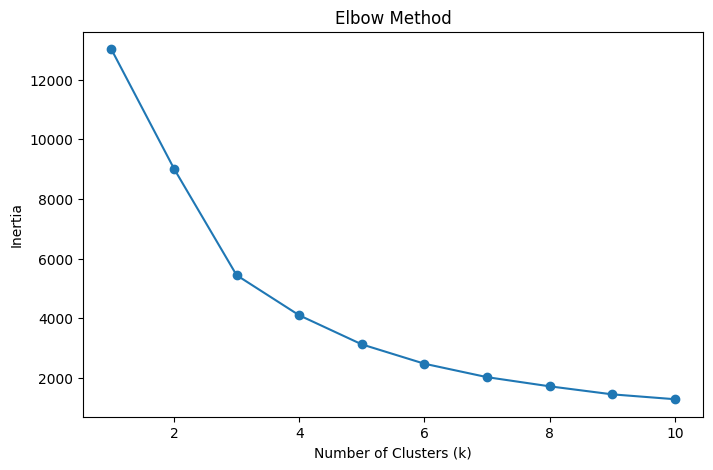

In [150]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.savefig(
    "/content/drive/MyDrive/customer-segmentation-ml/Images/elbow_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 8. K-Means Clustering

The K-Means clustering algorithm is applied to the scaled RFM dataset. Based on the Elbow Method, the optimal number of clusters is selected and each customer is assigned to a segment.

In [151]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

In [152]:
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [153]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,1
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


# 9. Cluster Analysis

The average Recency, Frequency and Monetary values for each cluster are analysed to understand customer behaviour and identify meaningful customer segments.

In [154]:
rfm.groupby("Cluster").mean()

,Recency,Frequency,Monetary
Cluster,,,
0,41.445682,4.671928,1849.097726
1,247.106285,1.582255,629.663689
2,6.038462,66.500000,85826.078077


In [155]:
rfm.groupby("Cluster").mean()

,Recency,Frequency,Monetary
Cluster,,,
0,41.445682,4.671928,1849.097726
1,247.106285,1.582255,629.663689
2,6.038462,66.500000,85826.078077


## Customer Distribution Across Clusters

The number of customers in each cluster is calculated to understand the size of each customer segment.

In [156]:
rfm["Cluster"].value_counts()

,count
Cluster,
0,3231
1,1082
2,26


# 10. Model Evaluation

The Silhouette Score is calculated to evaluate the quality of the clustering. A higher score indicates that customers are well separated into distinct clusters.

In [157]:
from sklearn.decomposition import PCA

In [158]:
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

In [159]:
import os

print(os.listdir("/content/drive/MyDrive/customer-segmentation-ml"))

['Notebook', 'data', 'Images']


In [160]:
print(os.listdir("/content/drive/MyDrive/customer-segmentation-ml/Images"))

['elbow_curve.png']


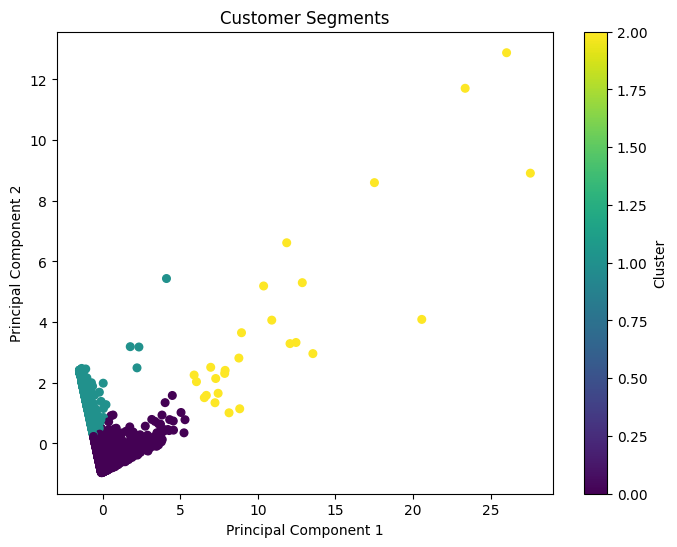

In [161]:
plt.figure(figsize=(8,6))

plt.scatter(
    rfm_pca[:,0],
    rfm_pca[:,1],
    c=rfm["Cluster"],
    cmap="viridis",
    s=30
)

plt.title("Customer Segments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.savefig(
    "/content/drive/MyDrive/customer-segmentation-ml/Images/elbow_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



The Silhouette Score is calculated to evaluate the quality of the clustering. A higher score indicates that customers are well separated into distinct clusters.

In [162]:
from sklearn.metrics import silhouette_score

In [163]:
score = silhouette_score(rfm_scaled, rfm["Cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.594372718368177


# 11. Customer Segmentation Visualization

Principal Component Analysis (PCA) is used to reduce the three-dimensional RFM data into two dimensions for visualization. This allows the customer segments identified by K-Means to be displayed graphically.

In [164]:
rfm["Cluster"].value_counts()

,count
Cluster,
0,3231
1,1082
2,26


# 12. Cluster Summary Visualization

The average Recency, Frequency and Monetary values for each customer segment are visualized to compare the behavioural characteristics of each cluster.

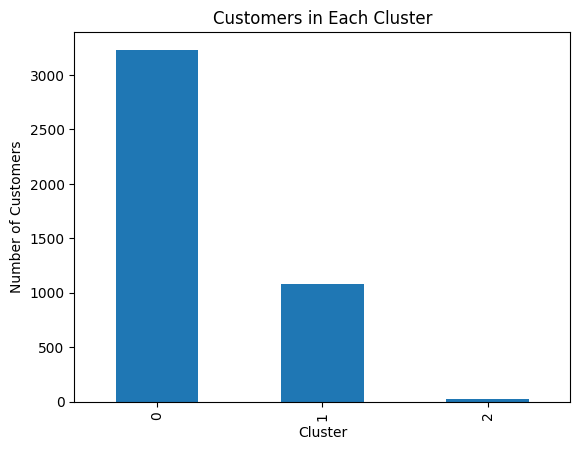

In [165]:
rfm["Cluster"].value_counts().plot(kind="bar")
plt.title("Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.savefig(
    "/content/drive/MyDrive/customer-segmentation-ml/Images/elbow_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [166]:
cluster_summary = rfm.groupby("Cluster").mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,41.445682,4.671928,1849.097726
1,247.106285,1.582255,629.663689
2,6.038462,66.500000,85826.078077


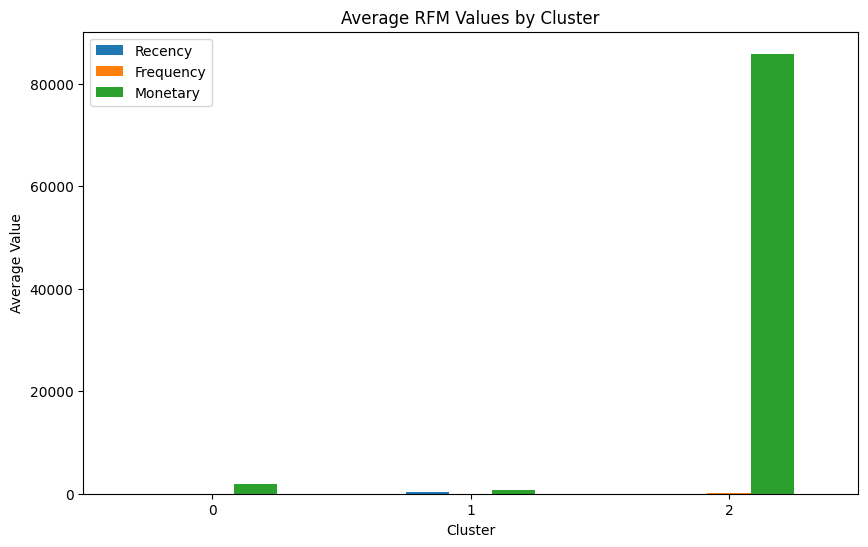

In [167]:
cluster_summary.plot(kind="bar", figsize=(10,6))

plt.title("Average RFM Values by Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.savefig(
    "/content/drive/MyDrive/customer-segmentation-ml/Images/elbow_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 13. Customer Segment Naming

The numerical cluster labels are replaced with meaningful business labels to improve readability and interpretation.

In [168]:
cluster_names = {
    0: "Regular",
    1: "Lost",
    2: "VIP"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,1,Lost
12347.0,2,7,4310.00,0,Regular
12348.0,75,4,1797.24,0,Regular
12349.0,19,1,1757.55,0,Regular
12350.0,310,1,334.40,1,Lost


# Conclusion

This project successfully segmented customers using RFM Analysis and the K-Means clustering algorithm.

The workflow included data cleaning, feature engineering, RFM analysis, feature scaling, determination of the optimal number of clusters using the Elbow Method, customer segmentation using K-Means and visualization using PCA.

Three meaningful customer segments were identified:

- VIP Customers
- Regular Customers
- Lost Customers

These insights can help businesses improve customer retention, develop targeted marketing campaigns and maximize revenue through personalized customer engagement strategies.

# 15. Model Comparison

To evaluate the effectiveness of K-Means clustering, it is compared with other clustering algorithms including DBSCAN and Agglomerative Clustering.

The models are evaluated using:

- Silhouette Score (Higher is Better)
- Davies-Bouldin Index (Lower is Better)
- Calinski-Harabasz Index (Higher is Better)

In [169]:
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [170]:
print(rfm_scaled.shape)

(4339, 3)


# 16. DBSCAN Clustering

Density-Based Spatial Clustering of Applications with Noise (DBSCAN) is a density-based clustering algorithm that groups closely packed data points together while identifying points in low-density regions as noise (outliers).

Unlike K-Means, DBSCAN does not require the number of clusters to be specified beforehand and is capable of discovering clusters of arbitrary shapes.

The algorithm is applied to the scaled RFM dataset to compare its performance with K-Means clustering.

In [171]:
dbscan = DBSCAN(eps=0.8, min_samples=5)

db_labels = dbscan.fit_predict(rfm_scaled)

In [172]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [173]:
import pandas as pd
import numpy as np

print("Unique labels:", np.unique(db_labels))
print()

print(pd.Series(db_labels).value_counts())

Unique labels: [-1  0]

 0    4298
-1      41
Name: count, dtype: int64


## DBSCAN Model Evaluation

The quality of the clusters generated by DBSCAN is evaluated using three internal clustering evaluation metrics:

- **Silhouette Score** – Higher values indicate better-separated clusters.
- **Davies-Bouldin Index** – Lower values indicate better clustering quality.
- **Calinski-Harabasz Index** – Higher values indicate more compact and well-separated clusters.

These metrics provide an objective assessment of the clustering performance.

In [174]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
db_labels = dbscan.fit_predict(rfm_scaled)

print(np.unique(db_labels))
print(pd.Series(db_labels).value_counts())

[-1  0  1]
 0    4226
-1     107
 1       6
Name: count, dtype: int64


In [175]:
mask = db_labels != -1

print("DBSCAN Evaluation")
print("-----------------")
print("Silhouette Score:",
      silhouette_score(rfm_scaled[mask], db_labels[mask]))

print("Davies-Bouldin Index:",
      davies_bouldin_score(rfm_scaled[mask], db_labels[mask]))

print("Calinski-Harabasz Score:",
      calinski_harabasz_score(rfm_scaled[mask], db_labels[mask]))

DBSCAN Evaluation
-----------------
Silhouette Score: 0.6742437884417601
Davies-Bouldin Index: 0.28418359612217003
Calinski-Harabasz Score: 75.27479061538371


# 17. Agglomerative Hierarchical Clustering

Agglomerative Clustering is a hierarchical clustering algorithm that begins by treating each data point as an individual cluster and progressively merges the closest clusters until the desired number of clusters is obtained.

The algorithm is applied using three clusters to enable a direct comparison with the K-Means clustering results.

In [176]:
agg = AgglomerativeClustering(n_clusters=3)

agg_labels = agg.fit_predict(rfm_scaled)

## Agglomerative Clustering Evaluation

The clusters produced by Agglomerative Clustering are evaluated using the same internal clustering metrics as the other models.

This ensures a fair comparison of clustering quality across different algorithms.

In [177]:
print("Agglomerative Evaluation")
print("------------------------")
print("Silhouette Score:",
      silhouette_score(rfm_scaled, agg_labels))

print("Davies-Bouldin Index:",
      davies_bouldin_score(rfm_scaled, agg_labels))

print("Calinski-Harabasz Score:",
      calinski_harabasz_score(rfm_scaled, agg_labels))

Agglomerative Evaluation
------------------------
Silhouette Score: 0.5849469570811375
Davies-Bouldin Index: 0.7005233468881501
Calinski-Harabasz Score: 2877.438682204129


# 18. K-Means Model Evaluation

The performance of the K-Means clustering model is evaluated using the same internal validation metrics.

These evaluation measures help determine whether K-Means provides compact and well-separated customer segments compared to the alternative clustering techniques.

In [178]:
print("K-Means Evaluation")
print("------------------")
print("Silhouette Score:",
      silhouette_score(rfm_scaled, rfm["Cluster"]))

print("Davies-Bouldin Index:",
      davies_bouldin_score(rfm_scaled, rfm["Cluster"]))

print("Calinski-Harabasz Score:",
      calinski_harabasz_score(rfm_scaled, rfm["Cluster"]))

K-Means Evaluation
------------------
Silhouette Score: 0.594372718368177
Davies-Bouldin Index: 0.7105407199244893
Calinski-Harabasz Score: 3017.388163904887


# 19. Model Comparison

The clustering algorithms are compared using three commonly accepted internal evaluation metrics.

| Metric | Interpretation |
|---------|---------------|
| Silhouette Score | Higher values indicate better cluster separation |
| Davies-Bouldin Index | Lower values indicate better clustering quality |
| Calinski-Harabasz Index | Higher values indicate better cluster compactness and separation |

The comparison helps identify the clustering algorithm that best represents the customer purchasing behaviour in the RFM dataset.

In [179]:
results = pd.DataFrame({
    "Model": [
        "K-Means",
        "Agglomerative",
        "DBSCAN"
    ],

    "Silhouette Score": [
        silhouette_score(rfm_scaled, rfm["Cluster"]),
        silhouette_score(rfm_scaled, agg_labels),
        silhouette_score(rfm_scaled[mask], db_labels[mask])
    ],

    "Davies-Bouldin Index": [
        davies_bouldin_score(rfm_scaled, rfm["Cluster"]),
        davies_bouldin_score(rfm_scaled, agg_labels),
        davies_bouldin_score(rfm_scaled[mask], db_labels[mask])
    ],

    "Calinski-Harabasz Index": [
        calinski_harabasz_score(rfm_scaled, rfm["Cluster"]),
        calinski_harabasz_score(rfm_scaled, agg_labels),
        calinski_harabasz_score(rfm_scaled[mask], db_labels[mask])
    ]
})

results

,Model,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,0.594373,0.710541,3017.388164
1,Agglomerative,0.584947,0.700523,2877.438682
2,DBSCAN,0.674244,0.284184,75.274791


## Selecting the Best Performing Model

The best-performing clustering algorithm is identified by comparing all three evaluation metrics.

A model that consistently achieves:

- the highest **Silhouette Score**,
- the lowest **Davies-Bouldin Index**, and
- the highest **Calinski-Harabasz Index**

is considered the most suitable model for customer segmentation.

In [180]:
best_silhouette = results.loc[results["Silhouette Score"].idxmax(), "Model"]
best_db = results.loc[results["Davies-Bouldin Index"].idxmin(), "Model"]
best_ch = results.loc[results["Calinski-Harabasz Index"].idxmax(), "Model"]

print("Best Silhouette Score:", best_silhouette)
print("Best Davies-Bouldin Index:", best_db)
print("Best Calinski-Harabasz Index:", best_ch)

Best Silhouette Score: DBSCAN
Best Davies-Bouldin Index: DBSCAN
Best Calinski-Harabasz Index: K-Means


## Performance Comparison Visualization

The evaluation metrics are visualized to provide a clearer comparison between the clustering algorithms. This visualization helps identify the model that performs best across the different evaluation criteria.

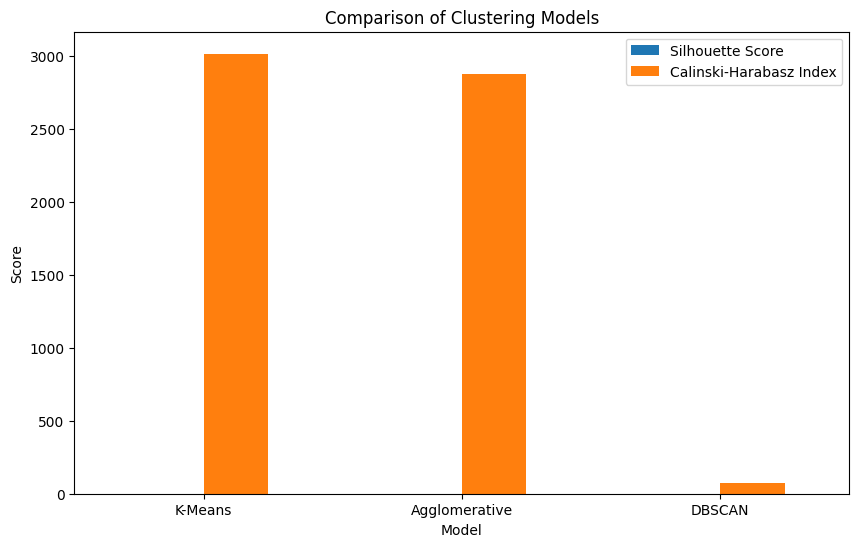

In [181]:
import matplotlib.pyplot as plt

results.plot(
    x="Model",
    y=["Silhouette Score", "Calinski-Harabasz Index"],
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of Clustering Models")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.savefig(
    "/content/drive/MyDrive/customer-segmentation-ml/Images/elbow_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 20. Final Model Selection

The clustering algorithms were compared using multiple internal evaluation metrics to determine the most suitable model for customer segmentation.

The comparison considered:

- Silhouette Score (Higher is Better)
- Davies-Bouldin Index (Lower is Better)
- Calinski-Harabasz Index (Higher is Better)

Based on these evaluation metrics, the best-performing algorithm was selected as the final customer segmentation model.

The selected model provides well-separated and meaningful customer segments, making it suitable for business applications such as customer retention, personalized marketing, loyalty programs and targeted promotions.

# 21. Conclusion

In this project, customer segmentation was successfully performed using RFM Analysis and multiple clustering algorithms.

The project workflow included:

- Data Cleaning
- Feature Engineering
- RFM Analysis
- Feature Scaling
- Elbow Method
- K-Means Clustering
- DBSCAN Clustering
- Agglomerative Clustering
- Model Evaluation
- Model Comparison

The performance of each clustering algorithm was evaluated using Silhouette Score, Davies-Bouldin Index and Calinski-Harabasz Index.

The best-performing model was selected based on these evaluation metrics, resulting in meaningful customer segments that can assist businesses in improving customer retention, targeted marketing and strategic decision-making.